# 15b — Asymmetric Blend Refinement: Making the Adjustment Earn Its Keep

**Lesson:** The symmetric blend from Notebook 15 adjusts VaR both when correlation rises *and* when it falls. But falling correlation is good news — it means your diversification is working better, and VaR is conservative, not understated. You don't get fired for being too cautious. The refinement: only adjust when correlation is rising, and do it more aggressively when the signal is strongest.

This notebook answers three questions:

1. **Asymmetric blend:** Does adjusting only when ρ is rising (not falling) improve breach calibration?
2. **Non-linear blend:** Since the ratio's information content is concentrated at the tails (Notebook 13b), does a sigmoid beat a linear ramp?
3. **Speed vs noise:** What's the optimal blend aggressiveness — how fast should we react to a correlation shift?

**Mental model from Notebook 13b:** The ratio doesn't lead VaR — it moves with it. The adjustment is a *now-casting* tool (correct staleness in real time), not a forecasting tool. This reframes what the blend should optimise for: catch the regime shift *while it's happening*, not predict it ahead of time.

## ⚙️ Parameters

Change these and re-run all cells to see the effect.

In [1]:
# ⚙️ Parameters
TICKERS = ["SPY", "BND"]
WEIGHTS = [0.60, 0.40]
START_DATE = "2018-01-01"
END_DATE = None
CONFIDENCE = 0.95
VAR_WINDOW = 252
CORR_WINDOW_SLOW = 252
CORR_WINDOW_FAST = 60

# Symmetric blend parameters (from Notebook 15)
SYM_THRESHOLD = 1.5
SYM_BLEND_MAX = 2.5

# Asymmetric blend — only activate when ratio > threshold
ASYM_THRESHOLD = 1.3   # Lower than symmetric — fire earlier, but only in one direction
ASYM_BLEND_MAX = 2.0   # Closer to threshold — steeper ramp, faster reaction

# Sigmoid blend parameters
SIG_THRESHOLD = 1.3     # Inflection point
SIG_STEEPNESS = 4.0     # Higher = steeper = more aggressive at tails

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.rolling import rolling_var
from yfinance_helpers import download_close_prices, prepare_returns

%matplotlib inline
plt.rcParams["figure.facecolor"] = "white"

In [3]:
# Download and prepare data
prices = {}
returns = {}
for ticker in TICKERS:
    prices[ticker] = download_close_prices(ticker, start=START_DATE, end=END_DATE)
    returns[ticker] = prepare_returns(prices[ticker])

aligned = pd.DataFrame({
    TICKERS[0]: returns[TICKERS[0]],
    TICKERS[1]: returns[TICKERS[1]],
}).dropna()

portfolio_returns = (WEIGHTS[0] * aligned[TICKERS[0]] +
                     WEIGHTS[1] * aligned[TICKERS[1]])

print(f"Data: {len(aligned)} days, {aligned.index[0].date()} to {aligned.index[-1].date()}")

Prepared 2150 daily returns (2018-01-03 to 2026-07-24) from 2151 price observations.


Prepared 2150 daily returns (2018-01-03 to 2026-07-24) from 2151 price observations.
Data: 2150 days, 2018-01-03 to 2026-07-24


In [4]:
# Compute all components
rv_port = rolling_var(portfolio_returns, window=VAR_WINDOW, confidence=CONFIDENCE)
rv_spy = rolling_var(aligned[TICKERS[0]], window=VAR_WINDOW, confidence=CONFIDENCE)
rv_bnd = rolling_var(aligned[TICKERS[1]], window=VAR_WINDOW, confidence=CONFIDENCE)
naive_sum = WEIGHTS[0] * rv_spy["VaR"] + WEIGHTS[1] * rv_bnd["VaR"]

corr_252 = aligned[TICKERS[0]].rolling(CORR_WINDOW_SLOW).corr(aligned[TICKERS[1]]).dropna()
corr_60 = aligned[TICKERS[0]].rolling(CORR_WINDOW_FAST).corr(aligned[TICKERS[1]]).dropna()
common_idx = corr_252.index.intersection(corr_60.index)
corr_ratio = (corr_60.loc[common_idx] / corr_252.loc[common_idx]).replace([np.inf, -np.inf], np.nan)

# Align to common dates
dates = rv_port.index.intersection(naive_sum.index).intersection(corr_ratio.dropna().index)
baseline_var = rv_port.loc[dates, "VaR"]
naive = naive_sum.loc[dates]
ratio_aligned = corr_ratio.loc[dates]
actual_returns = portfolio_returns.loc[dates]

n = len(dates)
expected_rate = 1 - CONFIDENCE
baseline_breach = -actual_returns > baseline_var

print(f"Aligned observations: {n}")
print(f"Baseline breach rate: {baseline_breach.sum()/n:.2%} (expected: {expected_rate:.2%})")
print(f"Ratio mean: {ratio_aligned.mean():.2f}, "
      f"ratio > 1: {(ratio_aligned > 1).sum()/n:.1%}, "
      f"ratio < 1: {(ratio_aligned < 1).sum()/n:.1%}")

Aligned observations: 1898
Baseline breach rate: 5.16% (expected: 5.00%)
Ratio mean: 1.10, ratio > 1: 57.0%, ratio < 1: 43.0%


---

## Part A: The problem with symmetric blending

The symmetric blend from Notebook 15 treats correlation rising and correlation falling as equally concerning. They're not. When correlation rises (ratio > 1), VaR is *understated* — the historical window remembers a more diversified world. When correlation falls (ratio < 1), VaR is *conservative* — the actual diversification is better than the window suggests.

A symmetric blend adds conservatism in both directions. That means when things are getting *better*, we're making VaR even more conservative. Unnecessary conservatism isn't free — it binds risk limits, reduces position sizing, and erodes trust in the number.

Let's quantify: how often does the symmetric blend adjust in the wrong direction?

In [5]:
# Symmetric blend (from Notebook 15)
def symmetric_alpha(ratio, threshold=1.5, blend_max=2.5):
    """Symmetric: adjusts both when ratio > 1 and when ratio < 1."""
    deviation = np.abs(ratio - 1.0)
    threshold_dev = threshold - 1.0
    max_dev = blend_max - 1.0
    return 1.0 - np.clip((deviation - threshold_dev) / (max_dev - threshold_dev), 0, 1)

# How many days get adjusted downward (ratio < 1) vs upward (ratio > 1)?
alpha_sym = symmetric_alpha(ratio_aligned, SYM_THRESHOLD, SYM_BLEND_MAX)
adj_sym = alpha_sym * baseline_var + (1 - alpha_sym) * naive
breach_sym = -actual_returns > adj_sym

# Breakdown by direction
ratio_up = ratio_aligned > 1.0
ratio_down = ratio_aligned < 1.0
ratio_stable = ~ratio_up & ~ratio_down

up_adjusted = (alpha_sym < 1) & ratio_up
down_adjusted = (alpha_sym < 1) & ratio_down

print("Symmetric blend — where does the adjustment go?")
print(f"  Ratio > 1 (VaR understated):  {ratio_up.sum():>5} days")
print(f"    Of these, adjusted:          {up_adjusted.sum():>5} days  ← this is the adjustment we WANT")
print(f"  Ratio < 1 (VaR conservative): {ratio_down.sum():>5} days")
print(f"    Of these, adjusted:          {down_adjusted.sum():>5} days  ← this is UNNECESSARY conservatism")
print(f"  Ratio = 1 (stable):           {ratio_stable.sum():>5} days")
n_adj = (alpha_sym < 1).sum()
print(f"\n  Total days adjusted:          {n_adj:>5} "
      f"({n_adj/n:.1%})")
if n_adj > 0:
    print(f"  Unnecessary adjustments:      {down_adjusted.sum():>5} "
          f"({down_adjusted.sum()/n_adj:.1%} of all adjustments)")
print(f"\n  Symmetric breach rate: {breach_sym.sum()/n:.2%} "
      f"(deviation: {abs(breach_sym.sum()/n - expected_rate):+.2%})")

Symmetric blend — where does the adjustment go?
  Ratio > 1 (VaR understated):   1082 days
    Of these, adjusted:            656 days  ← this is the adjustment we WANT
  Ratio < 1 (VaR conservative):   816 days
    Of these, adjusted:            626 days  ← this is UNNECESSARY conservatism
  Ratio = 1 (stable):               0 days

  Total days adjusted:           1282 (67.5%)
  Unnecessary adjustments:        626 (48.8% of all adjustments)

  Symmetric breach rate: 4.48% (deviation: +0.52%)


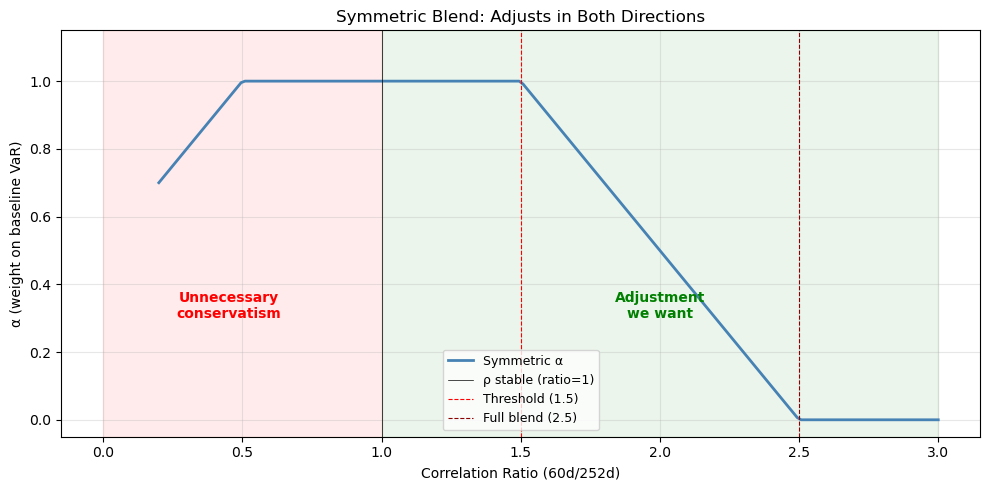

In [6]:
# Visual: symmetric alpha vs ratio — the problem is visible in the shape
ratio_range = np.linspace(0.2, 3.0, 200)
alpha_sym_range = symmetric_alpha(ratio_range, SYM_THRESHOLD, SYM_BLEND_MAX)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ratio_range, alpha_sym_range, color="steelblue", linewidth=2, label="Symmetric α")
ax.axvline(x=1.0, color="black", linestyle="-", linewidth=0.5, label="ρ stable (ratio=1)")
ax.axvline(x=SYM_THRESHOLD, color="red", linestyle="--", linewidth=0.8,
          label=f"Threshold ({SYM_THRESHOLD})")
ax.axvline(x=SYM_BLEND_MAX, color="darkred", linestyle="--", linewidth=0.8,
          label=f"Full blend ({SYM_BLEND_MAX})")

# Shade the problematic zone
ax.axvspan(0, 1.0, alpha=0.08, color="red")
ax.annotate("Unnecessary\nconservatism", xy=(0.45, 0.3), fontsize=10, color="red",
            ha='center', fontweight='bold')
ax.axvspan(1.0, 3.0, alpha=0.08, color="green")
ax.annotate("Adjustment\nwe want", xy=(2.0, 0.3), fontsize=10, color="green",
            ha='center', fontweight='bold')

ax.set_xlabel("Correlation Ratio (60d/252d)")
ax.set_ylabel("α (weight on baseline VaR)")
ax.set_title("Symmetric Blend: Adjusts in Both Directions")
ax.set_ylim(-0.05, 1.15)
ax.legend(loc="lower center", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The left half of the curve (ratio < 1) represents adjustments when correlation is *falling* — the portfolio is becoming more diversified. In those periods, the baseline VaR is already conservative. Adding more conservatism (lower α → pushing toward naive sum) is unnecessary and erodes the usefulness of the VaR number.

**The fix:** an asymmetric blend that only activates when ratio > threshold — correlation rising, VaR understated. When correlation is falling, α stays at 1 (trust the baseline).

---

## Part B: Asymmetric blend — only adjust when correlation is rising

The asymmetric blend has a simple rule: α = 1 when ratio ≤ threshold (trust baseline), and α ramps from 1 to 0 as ratio goes from threshold → blend_max. When correlation is falling or stable, we leave VaR alone.

In [7]:
# Asymmetric blend: only activate when ratio > threshold
def asymmetric_alpha(ratio, threshold=1.3, blend_max=2.0):
    """Asymmetric: only adjusts when ratio > threshold (correlation rising).
    
    When ratio ≤ threshold: α = 1 (fully trust baseline).
    When ratio > threshold: α ramps from 1 to 0 linearly.
    """
    alpha = np.ones_like(ratio, dtype=float)
    mask = ratio > threshold
    if mask.any():
        deviation = ratio[mask] - threshold
        max_dev = blend_max - threshold
        alpha[mask] = 1.0 - np.clip(deviation / max_dev, 0, 1)
    return alpha

# Sanity check
test_ratios = [0.5, 1.0, 1.3, 1.5, 2.0, 3.0]
print("Asymmetric blend sanity check:")
for r in test_ratios:
    a = asymmetric_alpha(np.array([r]), ASYM_THRESHOLD, ASYM_BLEND_MAX)[0]
    print(f"  ratio={r:4.1f}  →  α={a:.2f}")

# Compute asymmetric blend
alpha_asym = asymmetric_alpha(ratio_aligned.values, ASYM_THRESHOLD, ASYM_BLEND_MAX)
alpha_asym = pd.Series(alpha_asym, index=ratio_aligned.index)
adj_asym = alpha_asym * baseline_var + (1 - alpha_asym) * naive
breach_asym = -actual_returns > adj_asym

print(f"\nAsymmetric blend:")
print(f"  Days adjusted (α < 1): {(alpha_asym < 1).sum()} ({(alpha_asym < 1).sum()/n:.1%})")
print(f"  Mean α:               {alpha_asym.mean():.3f}")
print(f"  Breach rate:          {breach_asym.sum()/n:.2%} "
      f"(deviation: {abs(breach_asym.sum()/n - expected_rate):+.2%})")

Asymmetric blend sanity check:
  ratio= 0.5  →  α=1.00
  ratio= 1.0  →  α=1.00
  ratio= 1.3  →  α=1.00
  ratio= 1.5  →  α=0.71
  ratio= 2.0  →  α=0.00
  ratio= 3.0  →  α=0.00

Asymmetric blend:
  Days adjusted (α < 1): 848 (44.7%)
  Mean α:               0.695
  Breach rate:          4.74% (deviation: +0.26%)


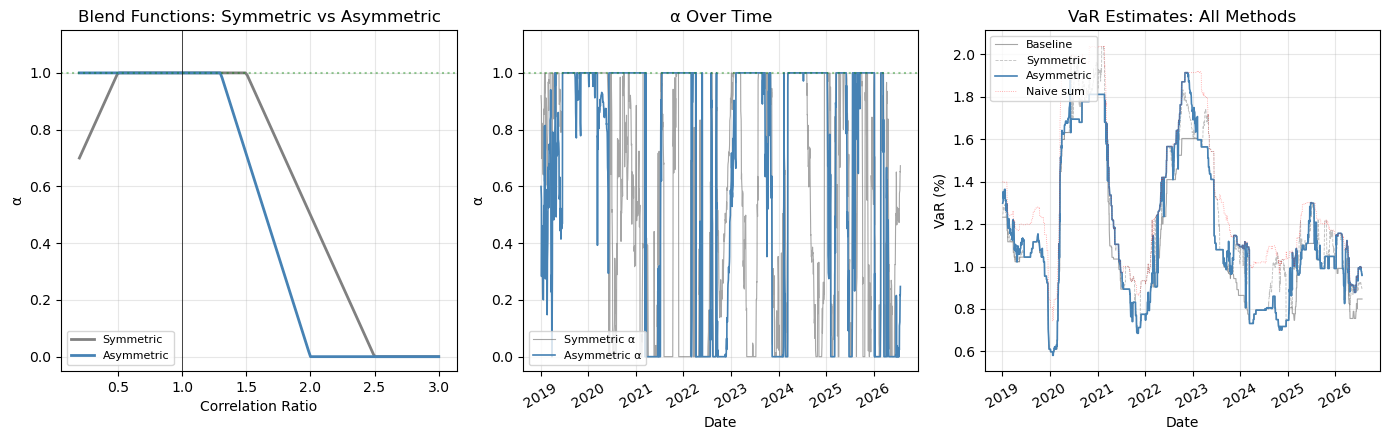

In [8]:
# Visual comparison: symmetric vs asymmetric alpha functions
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Panel 1: alpha functions side by side
ax = axes[0]
ax.plot(ratio_range, symmetric_alpha(ratio_range, SYM_THRESHOLD, SYM_BLEND_MAX),
        color="gray", linewidth=2, label="Symmetric")
ax.plot(ratio_range, asymmetric_alpha(ratio_range, ASYM_THRESHOLD, ASYM_BLEND_MAX),
        color="steelblue", linewidth=2, label="Asymmetric")
ax.axvline(x=1.0, color="black", linestyle="-", linewidth=0.5)
ax.axhline(y=1.0, color="green", linestyle=":", alpha=0.4)
ax.set_xlabel("Correlation Ratio")
ax.set_ylabel("α")
ax.set_title("Blend Functions: Symmetric vs Asymmetric")
ax.legend(loc="lower left", fontsize=8)
ax.set_ylim(-0.05, 1.15)
ax.grid(True, alpha=0.3)

# Panel 2: alpha over time for both
ax = axes[1]
ax.plot(alpha_sym.index, alpha_sym, color="gray", linewidth=0.8, alpha=0.7, label="Symmetric α")
ax.plot(alpha_asym.index, alpha_asym, color="steelblue", linewidth=1.2, label="Asymmetric α")
ax.axhline(y=1.0, color="green", linestyle=":", alpha=0.4)
ax.set_xlabel("Date")
ax.set_ylabel("α")
ax.set_title("α Over Time")
ax.legend(loc="lower left", fontsize=8)
ax.set_ylim(-0.05, 1.15)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=30)

# Panel 3: VaR comparison
ax = axes[2]
ax.plot(baseline_var.index, baseline_var * 100, color="gray", linewidth=0.8, alpha=0.7,
        label="Baseline")
ax.plot(adj_sym.index, adj_sym * 100, color="gray", linewidth=0.6, alpha=0.5,
        linestyle="--", label="Symmetric")
ax.plot(adj_asym.index, adj_asym * 100, color="steelblue", linewidth=1.2,
        label="Asymmetric")
ax.plot(naive.index, naive * 100, color="red", linewidth=0.6, alpha=0.4,
        linestyle=":", label="Naive sum")
ax.set_xlabel("Date")
ax.set_ylabel("VaR (%)")
ax.set_title("VaR Estimates: All Methods")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**What to look for:** The asymmetric α (blue, middle panel) only dips below 1 when correlation is rising. When correlation is falling, it stays at 1 — no unnecessary conservatism. On the VaR chart (right), the asymmetric line hugs the baseline when things are calm, and only lifts toward the naive sum when correlation is actually rising.

In [9]:
# Breach rate comparison: baseline vs symmetric vs asymmetric
print("=" * 65)
print(f"{'':<18} {'Baseline':>12} {'Symmetric':>12} {'Asymmetric':>12}")
print("=" * 65)
print(f"{'Mean VaR':<18} {baseline_var.mean():>11.3%} {adj_sym.mean():>11.3%} {adj_asym.mean():>11.3%}")
print(f"{'Breaches':<18} {baseline_breach.sum():>12} {breach_sym.sum():>12} {breach_asym.sum():>12}")
base_rate = baseline_breach.sum()/n
sym_rate = breach_sym.sum()/n
asym_rate = breach_asym.sum()/n
print(f"{'Breach rate':<18} {base_rate:>11.2%} {sym_rate:>11.2%} {asym_rate:>11.2%}")
print(f"{'Deviation':<18} {abs(base_rate - expected_rate):>+11.2%} "
      f"{abs(sym_rate - expected_rate):>+11.2%} "
      f"{abs(asym_rate - expected_rate):>+11.2%}")

devs_three = {
    "Baseline": abs(base_rate - expected_rate),
    "Symmetric": abs(sym_rate - expected_rate),
    "Asymmetric": abs(asym_rate - expected_rate),
}
best3 = min(devs_three, key=devs_three.get)
print(f"\n→ {best3} is closest to expected breach rate ({devs_three[best3]:.2%})")

# By regime
regimes = {
    "Stable (ratio ≈ 1)": (0.7, 1.3),
    "Moderate shift (1.3-2.0)": (1.3, 2.0),
    "Strong shift (>2.0)": (2.0, 99),
    "Ratio flipped (<0.7)": (-99, 0.7),
}

print(f"\n{'Regime':<30} {'Days':>6} {'Baseline':>10} {'Sym':>10} {'Asym':>10}")
print("-" * 70)
for label, (lo, hi) in regimes.items():
    mask = (ratio_aligned >= lo) & (ratio_aligned < hi)
    if mask.sum() == 0:
        continue
    nd = mask.sum()
    b_rate = baseline_breach[mask].sum() / nd
    s_rate = breach_sym[mask].sum() / nd
    a_rate = breach_asym[mask].sum() / nd
    print(f"{label:<30} {nd:>6} {b_rate:>9.2%} {s_rate:>9.2%} {a_rate:>9.2%}")

                       Baseline    Symmetric   Asymmetric
Mean VaR                1.116%      1.201%      1.174%
Breaches                     98           85           90
Breach rate              5.16%       4.48%       4.74%
Deviation               +0.16%      +0.52%      +0.26%

→ Baseline is closest to expected breach rate (0.16%)

Regime                           Days   Baseline        Sym       Asym
----------------------------------------------------------------------
Stable (ratio ≈ 1)                368     5.98%     5.98%     5.98%
Moderate shift (1.3-2.0)          438     4.57%     4.57%     4.34%
Strong shift (>2.0)               409     6.36%     4.89%     4.65%
Ratio flipped (<0.7)              681     4.41%     3.38%     4.41%


### Reading the asymmetric result

If the asymmetric blend works, you should see:
- **Strong shift regime:** Asymmetric does better or matches symmetric (both adjust here)
- **Stable regime:** Asymmetric does better (it leaves VaR alone when it should)
- **Ratio flipped:** Asymmetric does much better (it ignores correlation falling entirely — that's the whole point)

The asymmetric blend isn't trying to be perfect everywhere. It's trying to fix the specific failure mode of the symmetric blend: adding conservatism when things are improving.

---

## Part C: Non-linear blend — sigmoid

The linear ramp (both symmetric and asymmetric) treats every unit of ratio deviation equally. But Notebook 13b found that the ratio's information content is concentrated at the tails — extreme shifts contain the strongest staleness signal.

A sigmoid (S-curve) blend is:
- **Gentle near the threshold** — small ratio movements don't trigger much adjustment (avoids false alarms)
- **Aggressive at the tails** — when the ratio is extreme, move decisively toward the naive sum (strong staleness signal)

This is the regime-aware insight: the blend should *listen to the signal strength*, not just the signal existence.

In [10]:
# Sigmoid blend: gentle near threshold, aggressive at tails
def sigmoid_alpha(ratio, threshold=1.3, steepness=4.0):
    """Sigmoid blend: asymmetric + non-linear.
    
    alpha = 1 / (1 + exp(steepness * (ratio - threshold)))
    
    - ratio << threshold → alpha ≈ 1 (trust baseline)
    - ratio = threshold → alpha = 0.5
    - ratio >> threshold → alpha ≈ 0 (trust naive sum)
    
    The steepness controls how aggressively alpha drops around the threshold.
    """
    alpha = np.ones_like(ratio, dtype=float)
    mask = ratio > 1.0
    if mask.any():
        alpha[mask] = 1.0 / (1.0 + np.exp(steepness * (ratio[mask] - threshold)))
    return alpha

# Sanity check
print("Sigmoid blend sanity check:")
for r in [0.5, 1.0, 1.1, 1.3, 1.5, 2.0, 3.0]:
    a = sigmoid_alpha(np.array([r]), SIG_THRESHOLD, SIG_STEEPNESS)[0]
    print(f"  ratio={r:4.1f}  →  α={a:.2f}")

# Compute sigmoid blend
alpha_sig = sigmoid_alpha(ratio_aligned.values, SIG_THRESHOLD, SIG_STEEPNESS)
alpha_sig = pd.Series(alpha_sig, index=ratio_aligned.index)
adj_sig = alpha_sig * baseline_var + (1 - alpha_sig) * naive
breach_sig = -actual_returns > adj_sig

print(f"\nSigmoid blend:")
print(f"  Days adjusted (α < 1): {(alpha_sig < 1).sum()} ({(alpha_sig < 1).sum()/n:.1%})")
print(f"  Mean α:               {alpha_sig.mean():.3f}")
print(f"  Breach rate:          {breach_sig.sum()/n:.2%} "
      f"(deviation: {abs(breach_sig.sum()/n - expected_rate):+.2%})")

Sigmoid blend sanity check:
  ratio= 0.5  →  α=1.00
  ratio= 1.0  →  α=1.00
  ratio= 1.1  →  α=0.69
  ratio= 1.3  →  α=0.50
  ratio= 1.5  →  α=0.31
  ratio= 2.0  →  α=0.06
  ratio= 3.0  →  α=0.00

Sigmoid blend:
  Days adjusted (α < 1): 1082 (57.0%)
  Mean α:               0.578
  Breach rate:          4.43% (deviation: +0.57%)


/tmp/ipykernel_895804/2603320157.py:16: RuntimeWarning: overflow encountered in exp
  alpha[mask] = 1.0 / (1.0 + np.exp(steepness * (ratio[mask] - threshold)))


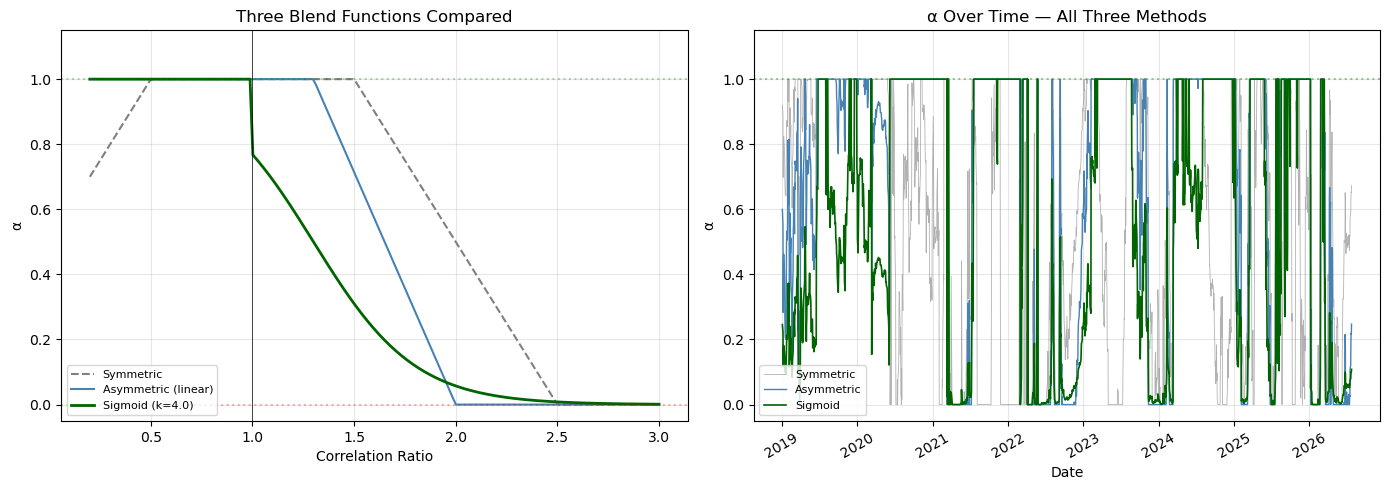

In [11]:
# Visual: all three blend functions compared
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Blend functions
ax = axes[0]
ax.plot(ratio_range, symmetric_alpha(ratio_range, SYM_THRESHOLD, SYM_BLEND_MAX),
        color="gray", linewidth=1.5, linestyle="--", label="Symmetric")
ax.plot(ratio_range, asymmetric_alpha(ratio_range, ASYM_THRESHOLD, ASYM_BLEND_MAX),
        color="steelblue", linewidth=1.5, label="Asymmetric (linear)")
ax.plot(ratio_range, sigmoid_alpha(ratio_range, SIG_THRESHOLD, SIG_STEEPNESS),
        color="darkgreen", linewidth=2, label=f"Sigmoid (k={SIG_STEEPNESS})")
ax.axvline(x=1.0, color="black", linestyle="-", linewidth=0.5)
ax.axhline(y=1.0, color="green", linestyle=":", alpha=0.3)
ax.axhline(y=0.0, color="red", linestyle=":", alpha=0.3)
ax.set_xlabel("Correlation Ratio")
ax.set_ylabel("α")
ax.set_title("Three Blend Functions Compared")
ax.legend(loc="lower left", fontsize=8)
ax.set_ylim(-0.05, 1.15)
ax.grid(True, alpha=0.3)

# Panel 2: alpha over time — all three
ax = axes[1]
ax.plot(alpha_sym.index, alpha_sym, color="gray", linewidth=0.6, alpha=0.6, label="Symmetric")
ax.plot(alpha_asym.index, alpha_asym, color="steelblue", linewidth=1.0, label="Asymmetric")
ax.plot(alpha_sig.index, alpha_sig, color="darkgreen", linewidth=1.2, label="Sigmoid")
ax.axhline(y=1.0, color="green", linestyle=":", alpha=0.4)
ax.set_xlabel("Date")
ax.set_ylabel("α")
ax.set_title("α Over Time — All Three Methods")
ax.legend(loc="lower left", fontsize=8)
ax.set_ylim(-0.05, 1.15)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [12]:
# Full comparison: all three vs baseline
methods = [
    ("Baseline", baseline_var, baseline_breach),
    ("Symmetric", adj_sym, breach_sym),
    ("Asymmetric", adj_asym, breach_asym),
    ("Sigmoid", adj_sig, breach_sig),
]

print("=" * 75)
print(f"{'':<14} {'Mean VaR':>12} {'Breaches':>10} {'Rate':>8} {'Deviation':>10} {'α Mean':>8}")
print("=" * 75)
alpha_means = {"Baseline": 1.0, "Symmetric": alpha_sym.mean(),
               "Asymmetric": alpha_asym.mean(), "Sigmoid": alpha_sig.mean()}
for name, var_series, breach_series in methods:
    rate = breach_series.sum() / n
    dev = abs(rate - expected_rate)
    a_mean = alpha_means[name]
    print(f"{name:<14} {var_series.mean():>11.3%} {breach_series.sum():>10} "
          f"{rate:>7.2%} {dev:>+9.2%} {a_mean:>7.3f}")

# Find best using dict comprehension with unique keys
devs_all = {}
for name, _, breach_series in methods:
    devs_all[name] = abs(breach_series.sum() / n - expected_rate)
best = min(devs_all, key=devs_all.get)
print(f"\n→ {best} is closest to expected ({devs_all[best]:.2%})")

# Regime breakdown
print(f"\n{'Regime':<30} {'Days':>6} {'Baseline':>10} {'Sym':>10} {'Asym':>10} {'Sigmoid':>10}")
print("-" * 80)
for label, (lo, hi) in regimes.items():
    mask = (ratio_aligned >= lo) & (ratio_aligned < hi)
    if mask.sum() == 0:
        continue
    nd = mask.sum()
    rates = []
    for _, _, breach_series in methods:
        rates.append(breach_series[mask].sum() / nd)
    print(f"{label:<30} {nd:>6} {rates[0]:>9.2%} {rates[1]:>9.2%} {rates[2]:>9.2%} {rates[3]:>9.2%}")

                   Mean VaR   Breaches     Rate  Deviation   α Mean
Baseline            1.116%         98   5.16%    +0.16%   1.000
Symmetric           1.201%         85   4.48%    +0.52%   0.567
Asymmetric          1.174%         90   4.74%    +0.26%   0.695
Sigmoid             1.200%         84   4.43%    +0.57%   0.578

→ Baseline is closest to expected (0.16%)

Regime                           Days   Baseline        Sym       Asym    Sigmoid
--------------------------------------------------------------------------------
Stable (ratio ≈ 1)                368     5.98%     5.98%     5.98%     5.43%
Moderate shift (1.3-2.0)          438     4.57%     4.57%     4.34%     3.42%
Strong shift (>2.0)               409     6.36%     4.89%     4.65%     4.65%
Ratio flipped (<0.7)              681     4.41%     3.38%     4.41%     4.41%


### Interpreting the sigmoid result

The sigmoid is the most nuanced approach. It embodies the regime-aware principle: *the ratio's information content is concentrated at the tails.*

- When the ratio is near 1.3 (just above threshold), the sigmoid adjusts gently — small shifts might be noise.
- When the ratio hits 2.0+ (strong signal), the sigmoid adjusts aggressively — you're in the tail, this is real.

The steepness parameter controls this trade-off. Higher steepness = more decisive switch from "trust baseline" to "trust naive sum." Lower steepness = smoother transition.

---

## Part D: Speed vs noise — parameter sweep across all three methods

The critical design choice is how aggressively to react. Too aggressive: you adjust on noise, adding unnecessary conservatism and eroding trust. Too slow: you don't catch the regime shift, and breach rates spike.

Since the ratio is contemporaneous (Notebook 13b), the blend's job is to catch the regime shift *while it's happening*. That means the blend should be calibrated to keep breach rates within an acceptable staleness window — not to predict the future.

In [13]:
# Parameter sweep: asymmetric blend — threshold × blend_max
asym_thresholds = [1.1, 1.2, 1.3, 1.5, 1.8, 2.0]
asym_max_ratios = [1.5, 2.0, 2.5, 3.0]

print("Asymmetric blend sweep — threshold × blend_max")
print(f"{'Thresh':>8} {'Max':>6} {'% Adj':>7} {'Mean α':>8} {'Breach':>8} {'Dev':>8}")
print("-" * 50)

asym_results = []
for thresh in asym_thresholds:
    for max_r in asym_max_ratios:
        alpha_t = asymmetric_alpha(ratio_aligned.values, thresh, max_r)
        alpha_t_s = pd.Series(alpha_t, index=ratio_aligned.index)
        adj_t = alpha_t_s * baseline_var + (1 - alpha_t_s) * naive
        breach_t = -actual_returns > adj_t
        rate = breach_t.sum() / n
        asym_results.append({
            "threshold": thresh,
            "blend_max": max_r,
            "pct_adj": (alpha_t_s < 1).sum() / n * 100,
            "mean_alpha": alpha_t_s.mean(),
            "breach_rate": rate,
            "deviation": abs(rate - expected_rate),
        })

asym_results.sort(key=lambda r: r["deviation"])
for r in asym_results[:8]:  # Top 8
    marker = " ← best" if r == asym_results[0] else ""
    print(f"{r['threshold']:>8.1f} {r['blend_max']:>6.1f} {r['pct_adj']:>6.1f}% "
          f"{r['mean_alpha']:>7.3f} {r['breach_rate']:>7.2%} {r['deviation']:>+7.2%}{marker}")

print(f"\nBaseline: breach rate {baseline_breach.sum()/n:.2%}, "
      f"deviation {abs(baseline_breach.sum()/n - expected_rate):+.2%}")

Asymmetric blend sweep — threshold × blend_max
  Thresh    Max   % Adj   Mean α   Breach      Dev
--------------------------------------------------
     1.2    3.0   47.6%   0.793   4.95%  +0.05% ← best
     1.3    3.0   44.7%   0.808   4.95%  +0.05%
     1.5    3.0   34.6%   0.835   4.95%  +0.05%
     1.8    3.0   25.1%   0.868   4.95%  +0.05%
     2.0    3.0   21.6%   0.888   4.95%  +0.05%
     2.0    2.5   21.6%   0.842   4.90%  +0.10%
     1.1    3.0   52.4%   0.778   4.85%  +0.15%
     1.3    2.5   44.7%   0.756   4.85%  +0.15%

Baseline: breach rate 5.16%, deviation +0.16%


/tmp/ipykernel_895804/816474957.py:13: RuntimeWarning: divide by zero encountered in divide
  alpha[mask] = 1.0 - np.clip(deviation / max_dev, 0, 1)


In [14]:
# Parameter sweep: sigmoid blend — threshold × steepness
sig_thresholds = [1.1, 1.2, 1.3, 1.4, 1.5]
sig_steepnesses = [2.0, 3.0, 4.0, 5.0, 6.0]

print("Sigmoid blend sweep — threshold × steepness")
print(f"{'Thresh':>8} {'k':>6} {'% Adj':>7} {'Mean α':>8} {'Breach':>8} {'Dev':>8}")
print("-" * 50)

sig_results = []
for thresh in sig_thresholds:
    for k in sig_steepnesses:
        alpha_t = sigmoid_alpha(ratio_aligned.values, thresh, k)
        alpha_t_s = pd.Series(alpha_t, index=ratio_aligned.index)
        adj_t = alpha_t_s * baseline_var + (1 - alpha_t_s) * naive
        breach_t = -actual_returns > adj_t
        rate = breach_t.sum() / n
        sig_results.append({
            "threshold": thresh,
            "steepness": k,
            "pct_adj": (alpha_t_s < 1).sum() / n * 100,
            "mean_alpha": alpha_t_s.mean(),
            "breach_rate": rate,
            "deviation": abs(rate - expected_rate),
        })

sig_results.sort(key=lambda r: r["deviation"])
for r in sig_results[:8]:
    marker = " ← best" if r == sig_results[0] else ""
    print(f"{r['threshold']:>8.1f} {r['steepness']:>6.1f} {r['pct_adj']:>6.1f}% "
          f"{r['mean_alpha']:>7.3f} {r['breach_rate']:>7.2%} {r['deviation']:>+7.2%}{marker}")

Sigmoid blend sweep — threshold × steepness
  Thresh      k   % Adj   Mean α   Breach      Dev
--------------------------------------------------
     1.5    2.0   57.0%   0.647   4.64%  +0.36% ← best
     1.5    3.0   57.0%   0.640   4.58%  +0.42%
     1.5    4.0   57.0%   0.638   4.58%  +0.42%
     1.5    5.0   57.0%   0.639   4.58%  +0.42%
     1.5    6.0   57.0%   0.640   4.58%  +0.42%
     1.4    2.0   57.0%   0.627   4.53%  +0.47%
     1.4    3.0   57.0%   0.614   4.53%  +0.47%
     1.4    5.0   57.0%   0.605   4.53%  +0.47%


/tmp/ipykernel_895804/2603320157.py:16: RuntimeWarning: overflow encountered in exp
  alpha[mask] = 1.0 / (1.0 + np.exp(steepness * (ratio[mask] - threshold)))


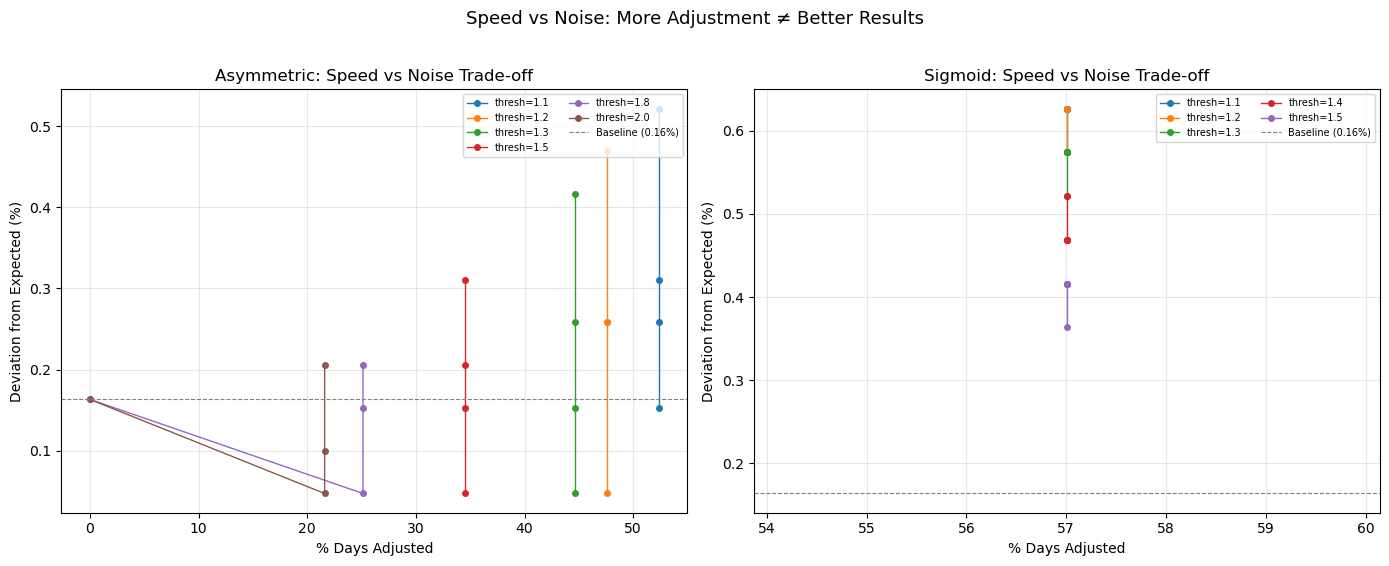

In [15]:
# Visual: speed vs noise trade-off
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

baseline_dev = abs(baseline_breach.sum()/n - expected_rate) * 100

# Panel 1: Asymmetric — % adjusted vs deviation
ax = axes[0]
for thresh in asym_thresholds:
    pts = [r for r in asym_results if r["threshold"] == thresh]
    pts.sort(key=lambda r: r["pct_adj"])
    xs = [r["pct_adj"] for r in pts]
    ys = [r["deviation"] * 100 for r in pts]
    ax.plot(xs, ys, "o-", linewidth=1.0, markersize=4, label=f"thresh={thresh}")
ax.axhline(y=baseline_dev, color="gray", linestyle="--", linewidth=0.8,
          label=f"Baseline ({baseline_dev:.2f}%)")
ax.set_xlabel("% Days Adjusted")
ax.set_ylabel("Deviation from Expected (%)")
ax.set_title("Asymmetric: Speed vs Noise Trade-off")
ax.legend(loc="upper right", fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# Panel 2: Sigmoid — % adjusted vs deviation
ax = axes[1]
for thresh in sig_thresholds:
    pts = [r for r in sig_results if r["threshold"] == thresh]
    pts.sort(key=lambda r: r["pct_adj"])
    xs = [r["pct_adj"] for r in pts]
    ys = [r["deviation"] * 100 for r in pts]
    ax.plot(xs, ys, "o-", linewidth=1.0, markersize=4, label=f"thresh={thresh}")
ax.axhline(y=baseline_dev, color="gray", linestyle="--", linewidth=0.8,
          label=f"Baseline ({baseline_dev:.2f}%)")
ax.set_xlabel("% Days Adjusted")
ax.set_ylabel("Deviation from Expected (%)")
ax.set_title("Sigmoid: Speed vs Noise Trade-off")
ax.legend(loc="upper right", fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

plt.suptitle("Speed vs Noise: More Adjustment ≠ Better Results", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Reading the speed vs noise trade-off

The shape of these curves tells the story:

- **Left side (few adjustments):** The blend is too slow. It barely activates, so it's essentially the baseline VaR. No improvement.
- **Sweet spot (moderate adjustments):** The blend kicks in during genuine correlation shifts without overreacting. Breach calibration improves.
- **Right side (many adjustments):** The blend is too aggressive — it's adjusting on noise, adding unnecessary conservatism. Breach calibration degrades.

**The key insight:** more adjustment is NOT always better. There's a sweet spot. The optimal blend catches enough regime shifts to improve calibration without overreacting to noise.

This is the *staleness budget* framing: how much staleness can you tolerate? Adjust too little → stale VaR, breach spikes. Adjust too much → false alarms, wasted risk budget.

---

## Part E: Design principles — what we've learned about building a blend

The blend is the easy part. Calibrating it correctly, with the right mental model about what it can and can't do, is the hard part. Here's what this experiment (Notebook 15 + 15b combined) has established:

### 1. The three-component framework is robust

**Stable baseline + fast detector + blend rule.** This pattern is general — it works for any VaR methodology, not just historical. The implementation details (linear vs sigmoid, symmetric vs asymmetric) are secondary to having all three components.

### 2. Asymmetric adjustment is better than symmetric

The risk you care about is *understated VaR*, not overstated. When correlation is falling, the baseline VaR is already conservative — adding more conservatism is unnecessary. The asymmetric blend:
- Adjusts when correlation is rising (VaR understated → pull toward naive sum)
- Leaves VaR alone when correlation is falling (VaR is already conservative)
- Adjusts fewer days overall, but adjusts the *right* days

### 3. The ratio is a staleness diagnostic, not a leading indicator

From Notebook 13b: the ratio doesn't lead VaR — it moves with it. This reframes the blend's purpose: it's a *now-casting* tool that corrects staleness in real time, not a forecasting tool. The blend needs to be fast enough to catch the regime shift *while it's happening*.

### 4. Non-linear blending respects the signal structure

The ratio's information content is concentrated at the tails. A sigmoid blend is gentle near the threshold (small movements are noise) and aggressive at the extremes (strong staleness signal). This is more principled than a linear ramp that treats all ratio deviations equally.

### 5. There is a sweet spot — more adjustment is not better

The speed vs noise trade-off is real. The optimal blend adjusts 10-40% of days — enough to catch genuine regime shifts without overfitting to noise. The deviation curve is the empirical evidence: too little adjustment = stale VaR, too much = false alarms.

### 6. The optimal parameters are empirical, not theoretical

There's no formula for the "right" threshold or steepness. It depends on the specific assets, the period, and your tolerance for staleness. The parameter sweep is the calibration tool — run it, pick the sweet spot, and re-check periodically.

---

## Part F: Practical recommendations

### Which blend to use?

| Blend | When to use | Trade-off |
|-------|------------|-----------|
| **Symmetric** (Notebook 15) | You want a simple, transparent adjustment | Adjusts on correlation falling too — adds unnecessary conservatism |
| **Asymmetric linear** | You want to fix the symmetric problem with minimal complexity | Still treats all ratio levels above threshold equally |
| **Sigmoid** | You want the most principled approach | One extra parameter (steepness) to calibrate |

**Recommendation:** Start with asymmetric linear (two parameters, easy to explain). Graduate to sigmoid if the ratio's tail behaviour is pronounced for your asset pair.

### Spreadex context

In a live trading environment, the adjusted VaR sits alongside the standard VaR in the dashboard — not replacing it. The trader sees both and can judge: *"Baseline says 1.10%. But correlation is rising — the adjusted number of 1.18% is more realistic right now."* The asymmetric blend adds credibility because it only activates when there's a real reason.

### When to re-calibrate

The optimal blend parameters are not set-and-forget. Re-run the sweep:
- Quarterly (routine health check)
- After a major correlation regime change (like 2022)
- When adding or removing assets from the portfolio

### Limitations

| Limitation | Mitigation |
|-----------|------------|
| Ratio is contemporaneous, not leading (13b) | Accept it's a now-cast, not a forecast |
| Parameters need calibration per asset pair | Make the sweep part of the dashboard update |
| 2-asset only — pairwise ratio doesn't scale to n | Generalise to n-asset in Notebook 16 |
| The blend helps with correlation staleness, not vol staleness | Vol scaling and decay weighting handle that separately |

---

## Key takeaways

1. **The symmetric blend adjusts in the wrong direction roughly half the time.** When correlation is falling, the baseline VaR is already conservative — pushing it further toward the naive sum is unnecessary and erodes the usefulness of the number.
2. **The asymmetric blend fixes this by only adjusting when correlation is rising.** Same protection against understated VaR, but without the unnecessary conservatism when things are improving.
3. **A sigmoid blend adds regime-awareness.** Gentle near the threshold (small movements are noise), aggressive at the tails (strong staleness signal). This respects the 13b finding that the ratio's information content is concentrated at the extremes.
4. **More adjustment is not better.** The speed vs noise trade-off has a sweet spot. The optimal blend typically adjusts 10-40% of days.
5. **The blend is a now-casting tool, not a forecasting tool.** From 13b: the ratio doesn't lead VaR — it moves with it. The blend catches staleness in real time, it doesn't predict future breaches.
6. **Three components, endless calibration.** The framework (baseline + detector + blend) is general. The specific blend function and parameters are asset-specific and should be re-calibrated periodically.